In [1]:
from pathlib import Path

# ────── Inputs ──────
# IMAGE_PATH   = "/home/songyu/Datasets/Autosurg/autosurg/output_frames/00202.jpg"
IMAGE_PATH   = "/home/songyu/Datasets/Autosurg/cuhk/Cali_Data_Needle_Image/needle_image/right/img_0022.jpg"
YOLO_WEIGHTS = "./models/yolo_weights/best.pt"

# ────── Detection / segmentation params ──────
YOLO_CONF  = 0.5
BOX_EXPAND = 1.0

# ────── Output ──────
OUTPUT_PATH = "Project/autosurg/results/sam_hq_vit_large/0022.png"
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

# ────── Device ──────
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


### Step 1 — YOLOv8 detection + box enlarge

Prior: exactly one needle per image → keep only the highest-confidence detection.

In [2]:
import numpy as np
from PIL import Image

def detect_and_enlarge(image_path, yolo_weights, conf=0.25, expand=1.0):
    """Run YOLOv8 and return the single highest-confidence enlarged box."""
    from ultralytics import YOLO

    model   = YOLO(yolo_weights)
    results = model(image_path, conf=conf)[0]

    img_h, img_w = results.orig_shape
    boxes_xyxy   = results.boxes.xyxy.cpu().numpy()
    confs        = results.boxes.conf.cpu().numpy()

    if len(boxes_xyxy) == 0:
        print("[WARN] YOLOv8 detected no needles")
        return np.array([]), img_w, img_h

    # Prior: one needle per image — keep only the top-confidence box
    best_idx = confs.argmax()
    if len(boxes_xyxy) > 1:
        print(f"  [INFO] {len(boxes_xyxy)} detections, keeping best "
              f"(idx={best_idx}, conf={confs[best_idx]:.3f})")

    x1, y1, x2, y2 = boxes_xyxy[best_idx]
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    w,  h  = (x2 - x1) * expand, (y2 - y1) * expand

    nx1 = max(0,     cx - w / 2)
    ny1 = max(0,     cy - h / 2)
    nx2 = min(img_w, cx + w / 2)
    ny2 = min(img_h, cy + h / 2)

    print(f"  original: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]  conf={confs[best_idx]:.3f}")
    print(f"  enlarged: [{nx1:.1f}, {ny1:.1f}, {nx2:.1f}, {ny2:.1f}]")
    return np.array([[nx1, ny1, nx2, ny2]]), img_w, img_h


boxes_xyxy, img_w, img_h = detect_and_enlarge(
    IMAGE_PATH, YOLO_WEIGHTS, conf=YOLO_CONF, expand=BOX_EXPAND
)
print(f"\nImage: {img_w} x {img_h}")
assert len(boxes_xyxy) > 0, "No needle detected — aborting."


image 1/1 /home/songyu/Datasets/Autosurg/cuhk/Cali_Data_Needle_Image/needle_image/right/img_0022.jpg: 384x640 1 suturing_needle, 58.6ms
Speed: 1.2ms preprocess, 58.6ms inference, 14.6ms postprocess per image at shape (1, 3, 384, 640)
  original: [828.8, 213.6, 1087.9, 359.3]  conf=0.665
  enlarged: [828.8, 213.6, 1087.9, 359.3]

Image: 1920 x 1080


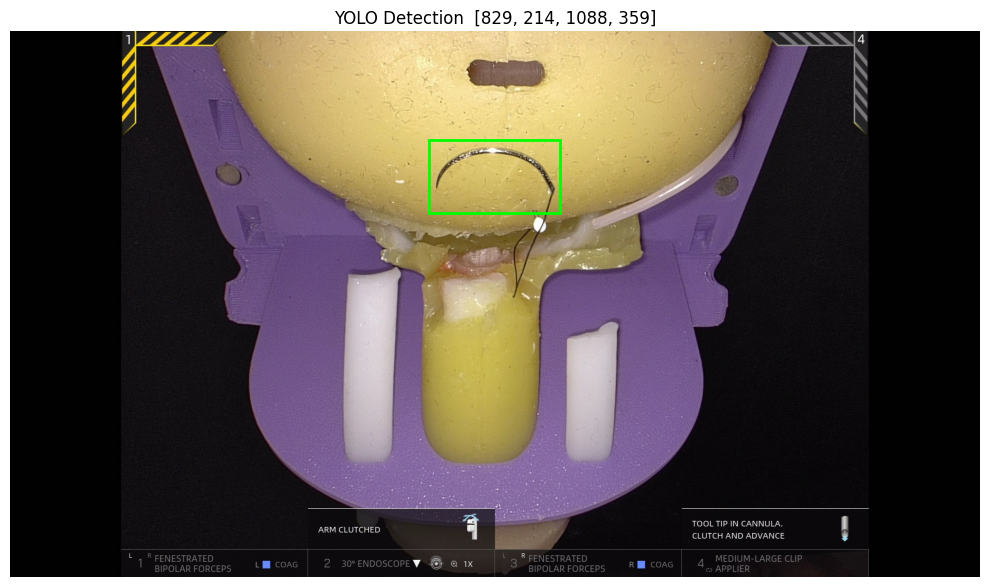

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

_img = PILImage.open(IMAGE_PATH).convert("RGB")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(np.array(_img))
x0, y0, x1, y1 = boxes_xyxy[0]
ax.add_patch(patches.Rectangle(
    (x0, y0), x1 - x0, y1 - y0,
    linewidth=2, edgecolor="lime", facecolor="none"
))
ax.set_title(f"YOLO Detection  [{x0:.0f}, {y0:.0f}, {x1:.0f}, {y1:.0f}]")
ax.axis("off")
plt.tight_layout()
plt.show()

### Step 2: Mask prompt SAM-HQ (use yolo box)

In [4]:
from transformers import SamHQModel, SamHQProcessor

SAMHQ_WEIGHTS = "./models/sam-hq-vit-large"
model = SamHQModel.from_pretrained(SAMHQ_WEIGHTS).to(DEVICE)
processor = SamHQProcessor.from_pretrained(SAMHQ_WEIGHTS)
print(f"SAM-HQ loaded from {SAMHQ_WEIGHTS}")

/home/songyu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 507/507 [00:00<00:00, 12793.21it/s]


SAM-HQ loaded from ./models/sam-hq-vit-large


In [5]:
import torch
from PIL import Image

raw_image = Image.open(IMAGE_PATH).convert("RGB")

# boxes_xyxy shape (1, 4) → SAM-HQ processor format [[[x1, y1, x2, y2]]]
input_boxes = [boxes_xyxy.tolist()]

inputs = processor(raw_image, input_boxes=input_boxes, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = model(**inputs, hq_token_only=True)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)
scores = outputs.iou_scores
# masks[0]: (num_boxes, num_masks_per_box, H, W) — hq_token_only=True → (1, 1, H, W)
# scores:   (batch, num_boxes, num_masks_per_box)
print(f"Mask shape: {masks[0].shape}  |  IoU scores: {scores[0]}")

Mask shape: torch.Size([1, 1, 1080, 1920])  |  IoU scores: tensor([[0.9191, 0.9047, 0.9042]], device='cuda:0')


Mask extent : y=[9, 1079]  x=[70, 1491]
Box region  : y=[214, 359]  x=[829, 1088]


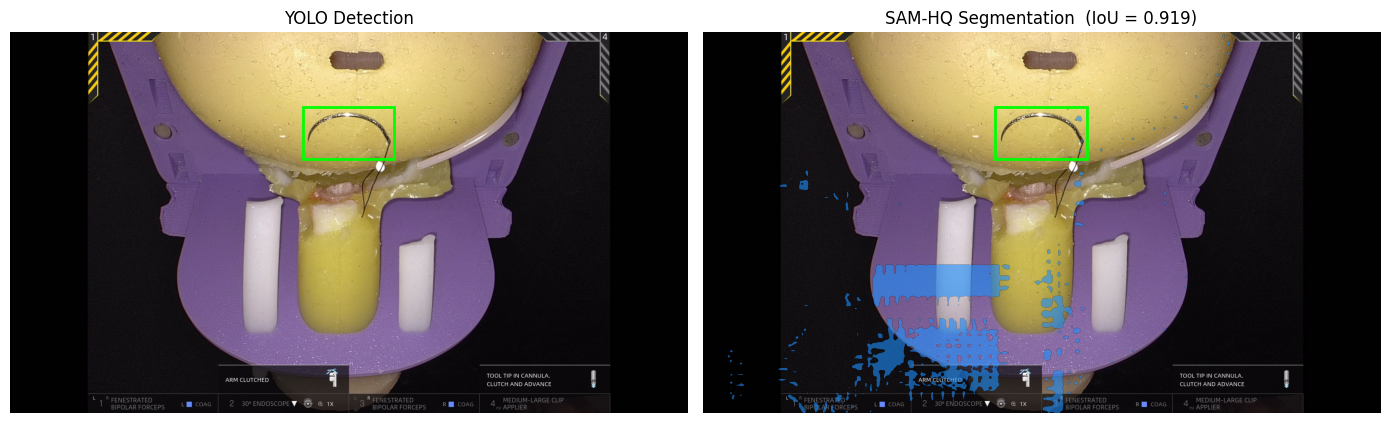

Saved → Project/autosurg/results/sam_hq_vit_large/0022.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_mask(mask, ax):
    color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, -1))

def show_box(box, ax):
    x0, y0, x1, y1 = box
    ax.add_patch(patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=2, edgecolor="lime", facecolor="none"
    ))

# hq_token_only=True → single HQ mask per box; scores shape (batch, num_boxes, 1)
best_mask = masks[0][0, 0].numpy()  # (H, W)
best_score = scores[0, 0, 0].item()

# Diagnostic: verify mask is inside the box
nz = best_mask.nonzero()
if len(nz[0]) > 0:
    print(f"Mask extent : y=[{nz[0].min()}, {nz[0].max()}]  x=[{nz[1].min()}, {nz[1].max()}]")
x0b, y0b, x1b, y1b = boxes_xyxy[0]
print(f"Box region  : y=[{y0b:.0f}, {y1b:.0f}]  x=[{x0b:.0f}, {x1b:.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(np.array(raw_image))
show_box(boxes_xyxy[0], axes[0])
axes[0].set_title("YOLO Detection")
axes[0].axis("off")

axes[1].imshow(np.array(raw_image))
show_mask(best_mask, axes[1])
show_box(boxes_xyxy[0], axes[1])
axes[1].set_title(f"SAM-HQ Segmentation  (IoU = {best_score:.3f})")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_PATH}")